In [1]:
# Imports
import path_simulator
import payoffs
from estimators import finite_difference
from estimators import pathwise
from estimators import likelihood_ratio

import numpy as np
import pandas as pd
import time

from scipy.stats import norm
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import LogLocator, FormatStrFormatter

Unlike the previous European and Asian call options, Digital call options do not have continuous payoff functions. However, their price function remains continuous in the underlying asset's price. Consequently, the Finite Differences and Likelihood Ratio methods remain valid to approximate the Delta of Digital call options, while Pathwise Differentiation fails in its original form.

Using risk-neutral valuation, the exact fair price of a Digital call option is given by

$$
V_{\mathrm{digital}}(S_0)=Qe^{-rT}\Phi(d_2),
\qquad
d_2=\frac{\ln(S_0/K)+\left(r-\frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}},
$$

where $Q$ is the fixed cash payoff received if $S_T>K$. This implies that the true Delta is given by 

$$
\Delta_{\mathrm{digital}}
=
\frac{\partial V_{\mathrm{digital}}}{\partial S_0}
=
Qe^{-rT}\phi(d_2)\frac{\partial d_2}{\partial S_0}
=
\frac{Qe^{-rT}\phi(d_2)}{S_0\sigma\sqrt{T}},
$$

where $\phi$ is the standard normal probability density function. This is used throughout this notebook.

We first define the parameters to be reused throughout this notebook and calculate the true value of the Delta.

In [2]:
# Parameters of the Digital call option
s = 100
K = 100
Q = 10 # fixed payoff
T = 1
r = 0.05
vol = 0.25
reps = 10000

In [3]:
# Compute the true Delta
d2 = (np.log(s/K) + (r - 0.5*(vol**2))*T) / (vol * np.sqrt(T))
real_delta = (Q * np.exp(-r*T) * norm.pdf(d2)) / (s * vol * np.sqrt(T))

## Finite Differences

We begin by investigating the accuracy of the Forward and Central Difference methods in the approximation of the Delta of the Digital call with the parameters specified above. 

Firstly, we focus on deriving optimal-$h$ functions taking the number of simulations $N$ as a parameter. Notice that investigating the fixed payoff $Q$ is unnecessary since this only scales all quantities (price, Delta, error, etc.) but doesn't modify the behaviour of the estimations. We focus on the Forward Difference method first.

In [4]:
# Values to investigate
reps_values = np.logspace(3, 6, 7, dtype=int)
h_values = np.logspace(-2, 2, 9)

In [5]:
trials = 5

# Rows correspond to reps, columns correspond to h
fd_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_fd = finite_difference.mc_digital_call_delta_fd_estimate(s,K,Q,T,r,vol,reps_i,h_j)
            trial_errors[trial] = (delta_fd - real_delta)**2
        fd_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
fd_error_table = pd.DataFrame(fd_mse, index=reps_values, columns=h_values)

fd_error_table.index.name = "reps"
fd_error_table.columns.name = "h"

display(fd_error_table)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,349.784853,29.882896,2.948308,0.365306,0.013041,0.002468,0.000477,0.001836,0.011499
3162,162.548109,12.148562,1.557396,0.322314,0.009384,0.001518,0.000230,0.002305,0.011266
10000,9.375597,11.389072,0.556872,0.034409,0.004308,0.000247,0.000160,0.002115,0.011437
31622,2.992707,2.069947,0.203841,0.010295,0.001973,0.000167,0.000189,0.002154,0.011366
100000,2.882638,0.797314,0.041783,0.000796,0.000094,0.000119,0.000138,0.002116,0.011437
316227,0.187957,0.090519,0.005722,0.003421,0.000258,0.000062,0.000165,0.002108,0.011419
1000000,0.186844,0.107111,0.000605,0.000921,0.000008,0.000013,0.000155,0.002116,0.011427


We observe the usual pattern along both axes. There is a clear concavity along the $h$ axis, while along the $reps$ axis the MSE decreases, in general, monotonically. We repeat the experiment for the Central Difference method.

In [6]:
trials = 5

# Rows correspond to reps, columns correspond to h
cd_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd = finite_difference.mc_digital_call_delta_cd_estimate(s,K,Q,T,r,vol,reps_i,h_j)
            trial_errors[trial] = (delta_cd - real_delta)**2
        cd_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
cd_error_table = pd.DataFrame(cd_mse, index=reps_values, columns=h_values)

cd_error_table.index.name = "reps"
cd_error_table.columns.name = "h"

display(cd_error_table)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,56.986369,24.725502,0.650770,0.109305,0.011745,5.004341e-04,0.000066,0.000908,0.010794
3162,27.961752,7.287921,0.666051,0.019933,0.002266,2.484896e-04,0.000045,0.000928,0.010801
10000,11.930950,2.055349,0.285988,0.012855,0.002524,3.121776e-05,0.000018,0.000903,0.010797
31622,3.273549,0.154792,0.036939,0.001298,0.000264,2.312724e-05,0.000017,0.000904,0.010797
100000,1.340161,0.195238,0.005393,0.002154,0.000272,1.303608e-05,0.000010,0.000906,0.010798
316227,0.613153,0.021345,0.000957,0.000266,0.000032,5.841460e-06,0.000010,0.000913,0.010797
1000000,0.061714,0.004782,0.000707,0.000043,0.000009,6.549458e-07,0.000012,0.000913,0.010797


As expected, CD produce a lower MSE relative to FD, but the pattern in the table is identical. We plot the results above for a better visual reference.

In [7]:
shared_vmin = min(fd_mse[fd_mse > 0].min(),cd_mse[cd_mse > 0].min())

shared_vmax = max(fd_mse.max(),cd_mse.max())

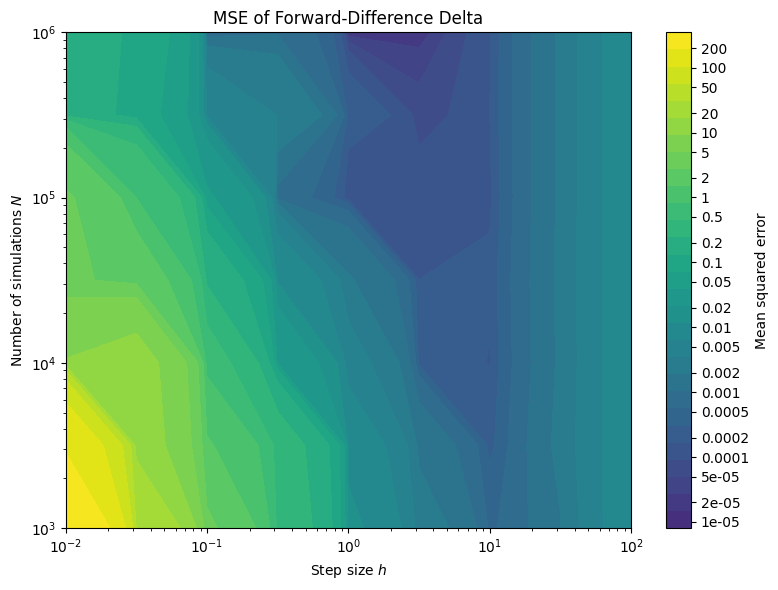

In [8]:
H, N = np.meshgrid(h_values, reps_values)

# Bounds of the plot
vmin = fd_mse[fd_mse > 0].min()
vmax = fd_mse.max()

plt.figure(figsize=(8, 6))

levels = np.geomspace(vmin, vmax, 30)
contour = plt.contourf(H,N,fd_mse,levels=levels,norm=LogNorm(vmin=shared_vmin, vmax=shared_vmax))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step size $h$")
plt.ylabel("Number of simulations $N$")
plt.title("MSE of Forward-Difference Delta")

cbar = plt.colorbar(contour)
cbar.locator = LogLocator(base=10,subs=(1, 2, 5),numticks=20)
cbar.formatter = FormatStrFormatter("%.3g")
cbar.update_ticks()
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

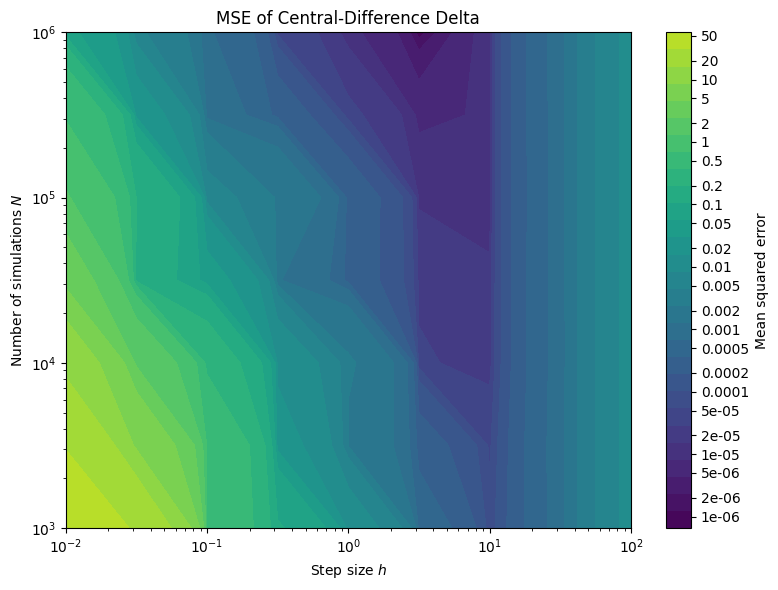

In [9]:
# Bounds for the plot
H, N = np.meshgrid(h_values, reps_values)

vmin = cd_mse[cd_mse > 0].min()
vmax = cd_mse.max()

plt.figure(figsize=(8, 6))

levels = np.geomspace(vmin, vmax, 30)
contour = plt.contourf(H,N,cd_mse,levels=levels,norm=LogNorm(vmin=shared_vmin, vmax=shared_vmax))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step size $h$")
plt.ylabel("Number of simulations $N$")
plt.title("MSE of Central-Difference Delta")

cbar = plt.colorbar(contour)
cbar.locator = LogLocator(base=10,subs=(1, 2, 5),numticks=20)
cbar.formatter = FormatStrFormatter("%.3g")
cbar.update_ticks()
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

The plots above are almost identical to those observed for Europeans and Asians. As done before, we estimate the optimal-$h$ functions taking $N$ as the only variable parameter. For Digital calls, the MSE surfaces for forward and central differences are approximated by

$$
\operatorname{MSE}_{\mathrm{FD}}(h,N)
\approx
A_{\mathrm{FD}}h^2+\frac{B_{\mathrm{FD}}}{Nh^2},
$$

and

$$
\operatorname{MSE}_{\mathrm{CD}}(h,N)
\approx
A_{\mathrm{CD}}h^4+\frac{B_{\mathrm{CD}}}{Nh^2},
$$

respectively, where $N$ denotes the number of repetitions and $A_{\mathrm{FD}},B_{\mathrm{FD}},A_{\mathrm{CD}},B_{\mathrm{CD}}>0$ are constants.

We estimate the coefficients that determine the surface below.

In [10]:
# Grid of values
reps_values_fit = np.unique(np.logspace(3, 5, 8, dtype=int))
h_values_fit = np.logspace(-1, 1, 12)

trials = 10

# Empirical MSE values
fd_mse_fit = np.empty((len(reps_values_fit), len(h_values_fit)))

for i, reps_i in enumerate(reps_values_fit):
    for j, h_j in enumerate(h_values_fit):
        squared_errors = np.empty(trials)
        for trial in range(trials):
            delta_fd = finite_difference.mc_digital_call_delta_fd_estimate(s,K,Q,T,r,vol,reps_i,h_j)
            squared_errors[trial] = (delta_fd - real_delta)**2
        fd_mse_fit[i, j] = np.mean(squared_errors)

# Prepare data for fitting
H, N = np.meshgrid(h_values_fit,reps_values_fit)

x_data = np.vstack([N.ravel(), H.ravel()])
y_data = fd_mse_fit.ravel()

# MSE(N,h) ≈ A h^2 + B / (N h^2)
def fd_mse_model(x, A, B):
    N, h = x
    return A * h**2 + B / (N * h**2)

# Estimate A and B
parameters, covariance = curve_fit(fd_mse_model,x_data,y_data,p0=(1e-4, 100),bounds=(0, np.inf))
A_hat_fd, B_hat_fd = parameters

# Print results
print(f"Estimated A = {A_hat_fd:.6e}")
print(f"Estimated B = {B_hat_fd:.6e}")

Estimated A = 7.794128e-06
Estimated B = 2.422240e+01


In [11]:
# Optimal h as a function of N (according to theory)
def h_opt_fd(N):
    return (B_hat_fd/(N*A_hat_fd))**(1/4)

In [12]:
# Print optimal values
print(f"Optimal step size for N = 1,000 : {h_opt_fd(1_000)}")
print(f"Optimal step size for N = 10,000 : {h_opt_fd(10_000)}")
print(f"Optimal step size for N = 100,000 : {h_opt_fd(100_000)}")
print(f"Optimal step size for N = 1,000,000 : {h_opt_fd(1_000_000)}")

Optimal step size for N = 1,000 : 7.46641954204107
Optimal step size for N = 10,000 : 4.198676259698495
Optimal step size for N = 100,000 : 2.36108917192411
Optimal step size for N = 1,000,000 : 1.3277380138323878


We repeat the above for the Central Difference method.

In [13]:
# Grid of values
reps_values_fit = np.unique(np.logspace(3, 5, 8, dtype=int))
h_values_fit = np.logspace(-1, 1, 12)

trials = 10

# Empirical MSE values
cd_mse_fit = np.empty((len(reps_values_fit), len(h_values_fit)))

for i, reps_i in enumerate(reps_values_fit):
    for j, h_j in enumerate(h_values_fit):
        squared_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd = finite_difference.mc_digital_call_delta_cd_estimate(s,K,Q,T,r,0.25,reps_i,h_j)
            squared_errors[trial] = (delta_cd - real_delta)**2
        cd_mse_fit[i, j] = np.mean(squared_errors)

# Prepare data for fitting
H, N = np.meshgrid(h_values_fit,reps_values_fit)

x_data = np.vstack([N.ravel(), H.ravel()])
y_data = cd_mse_fit.ravel()

# MSE(N,h) ≈ A h^2 + B / (N h^2)
def cd_mse_model(x, A, B):
    N, h = x
    return A * h**4 + B / (N * h**2)

# Estimate A and B
parameters, covariance = curve_fit(cd_mse_model,x_data,y_data,p0=(1e-4, 100),bounds=(0, np.inf))
A_hat_cd, B_hat_cd = parameters

# Print results
print(f"Estimated A = {A_hat_cd:.6e}")
print(f"Estimated B = {B_hat_cd:.6e}")

Estimated A = 4.920850e-09
Estimated B = 1.168387e+01


In [14]:
# Optimal h as a function of N (according to theory)
def h_opt_cd(N):
    return (B_hat_cd/(2*N*A_hat_cd))**(1/6)

In [15]:
# Print optimal values
print(f"Optimal step size for N = 1,000 : {h_opt_cd(1_000)}")
print(f"Optimal step size for N = 10,000 : {h_opt_cd(10_000)}")
print(f"Optimal step size for N = 100,000 : {h_opt_cd(100_000)}")
print(f"Optimal step size for N = 1,000,000 : {h_opt_cd(1_000_000)}")

Optimal step size for N = 1,000 : 10.290096367662125
Optimal step size for N = 10,000 : 7.01056104513034
Optimal step size for N = 100,000 : 4.776239639693993
Optimal step size for N = 1,000,000 : 3.254014186443772


These optimal-h findings are consistent with the results obtained in the table and plots above. 

Next, we implement Common Random Numbers aiming to reduce the magnitude of the MSE and done for European and Asian calls. We obtain the results for the same $N$-$h$ grid.

In [16]:
trials = 5

# Rows correspond to reps, columns correspond to h
fd_crn_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_fd_crn = finite_difference.mc_digital_call_delta_fd_estimate_crn(s,K,Q,T,r,vol,reps_i,h_j)
            trial_errors[trial] = (delta_fd_crn - real_delta)**2
        fd_crn_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
fd_crn_error_table = pd.DataFrame(fd_crn_mse, index=reps_values, columns=h_values)

fd_crn_error_table.index.name = "reps"
fd_crn_error_table.columns.name = "h"

display(fd_crn_error_table)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,0.146285,0.022796,0.015013,0.004391,0.002764,0.000447,0.000229,0.002068,0.011229
3162,0.058768,0.032773,0.006302,0.001506,0.001006,0.000088,0.000148,0.002137,0.011447
10000,0.014022,0.000532,0.000874,0.000340,0.000099,0.000015,0.000181,0.002161,0.011376
31622,0.002319,0.000989,0.000660,0.000221,0.000028,0.000013,0.000157,0.002069,0.011452
100000,0.001038,0.000677,0.000259,0.000044,0.000014,0.000021,0.000165,0.002150,0.011423
316227,0.000391,0.000296,0.000057,0.000005,0.000002,0.000020,0.000160,0.002122,0.011425
1000000,0.000033,0.000025,0.000009,0.000009,0.000004,0.000013,0.000160,0.002126,0.011426


In [17]:
trials = 5

# Rows correspond to reps, columns correspond to h
cd_crn_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd_crn = finite_difference.mc_digital_call_delta_cd_estimate_crn(s,K,Q,T,r,vol,reps_i,h_j)
            trial_errors[trial] = (delta_cd_crn - real_delta)**2
        cd_crn_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
cd_crn_error_table = pd.DataFrame(cd_crn_mse, index=reps_values, columns=h_values)

cd_crn_error_table.index.name = "reps"
cd_crn_error_table.columns.name = "h"

display(cd_crn_error_table)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,0.072246,0.027146,0.006984,0.001370,3.746177e-04,3.595748e-05,0.000057,0.000863,0.010805
3162,0.013633,0.010030,0.002502,0.000867,4.519646e-04,3.809296e-05,0.000013,0.000847,0.010803
10000,0.006079,0.001532,0.001141,0.000091,2.754400e-05,1.781480e-05,0.000005,0.000928,0.010796
31622,0.003036,0.000666,0.000160,0.000074,4.315224e-05,1.082882e-05,0.000014,0.000921,0.010798
100000,0.000268,0.000267,0.000090,0.000024,7.653507e-06,2.385822e-06,0.000010,0.000908,0.010797
316227,0.000101,0.000014,0.000004,0.000005,5.366705e-07,1.127617e-06,0.000009,0.000910,0.010798
1000000,0.000061,0.000005,0.000011,0.000004,2.102065e-07,2.158423e-07,0.000010,0.000909,0.010798


Just as for European calls, the implementation of CRN for the FD and CD methods is especially effective on the small-$h$ region, with a dramatic impact on the region with $h < 1$. Clearly, as the two underlying prices used in the approximation of the derivative are further apart, the effect of the underlying asset price's path not moving together (which is precisely the problem that CRN fixes) becomes less relevant. 

Overall, Finite Differences for Digital call options behave almost identically to how they behave for European call options. As mentioned, this is due to the fact that, despite the former having a discontinuous payoff function and the latter a continuous one, both option price functions are continuous.

## Pathwise Differentiation

The method of Pathwise Differentiation does not work in its original form for digital call options, due to the payoff discontinuity at $S_T=K$ and the consequent Dirac-like behaviour of the derivative at that point. In order to investigate some aspects of this method, however, we approximate the discontinuous step function $\mathbf{1}_{\{S_T>K\}}$ through a sequence of functions converging pointwise to it almost everywhere, namely

$$
g_n(x)
=
\Phi\left(\frac{x-K}{\varepsilon_n}\right),
\qquad
\varepsilon_n\downarrow0,
$$

where $\Phi$ is the standard normal cumulative distribution function.

Under this approximation, the smoothed Pathwise Differentiation Delta estimator is given by

$$
\widehat{\Delta}_{\mathrm{PW}}^{(n)}
=
\frac{Qe^{-rT}}{N}
\sum_{i=1}^{N}
g_n'\left(S_T^{(i)}\right)
\frac{S_T^{(i)}}{S_0}
=
\frac{Qe^{-rT}}{N}
\sum_{i=1}^{N}
\frac{1}{\varepsilon_n}
\phi\left(\frac{S_T^{(i)}-K}{\varepsilon_n}\right)
\frac{S_T^{(i)}}{S_0},
$$

where $\phi$ is the standard normal probability density function.

We begin by investigating the MSE of this Delta approximation on a $\varepsilon_n$-$N$ grid. Note that the MSE corresponds to the approximation of an ATM option, so we are estimating Delta preceisely at the discontinuity of the payoff function.

In [18]:
# Values to investigate
epsilon_values = np.logspace(-5, 2, 25)
reps_values = np.logspace(3, 6, 7, dtype=int)

In [19]:
trials = 10

# Rows correspond to moneyness, columns correspond to vol
pw_mse = np.empty((len(epsilon_values), len(reps_values)))

# Populate the table
for i, epsilon_i in enumerate(epsilon_values):
    for j, reps_j in enumerate(reps_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_pw = pathwise.mc_digital_call_delta_pw_estimate(s,K,Q,T,r,vol,reps_j,epsilon_i)
            trial_errors[trial] = (delta_pw - real_delta)**2
        pw_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
pw_error_table = pd.DataFrame(pw_mse, index=epsilon_values, columns=reps_values)

pw_error_table.index.name = "epsilon"
pw_error_table.columns.name = "reps"

display(pw_error_table)

reps,1000,3162,10000,31622,100000,316227,1000000
epsilon,,,,,,,
0.000010,0.022912,0.022912,0.022912,0.022912,0.020603,1.600257e-01,4.283022e-02
0.000020,0.022912,0.022912,0.022912,0.022908,0.019341,3.433871e-02,2.467504e-02
0.000038,0.022912,0.022912,0.022912,3.184198,0.073455,2.001831e-02,1.295254e-02
0.000075,0.022912,0.022912,2.373701,0.040892,0.072156,1.293939e-02,1.182889e-02
0.000147,0.022912,0.113455,0.021026,0.086231,0.012988,1.334841e-02,2.585246e-03
0.000287,0.027684,0.019551,0.129087,0.073932,0.005935,4.080975e-03,1.814584e-03
0.000562,0.022812,0.018882,0.022013,0.017576,0.008142,1.814705e-03,8.032973e-04
0.001101,0.022718,0.105857,0.021941,0.021383,0.006971,1.561534e-03,7.767826e-04
0.002154,0.020622,0.034211,0.016725,0.004268,0.001518,6.427355e-04,1.285505e-04


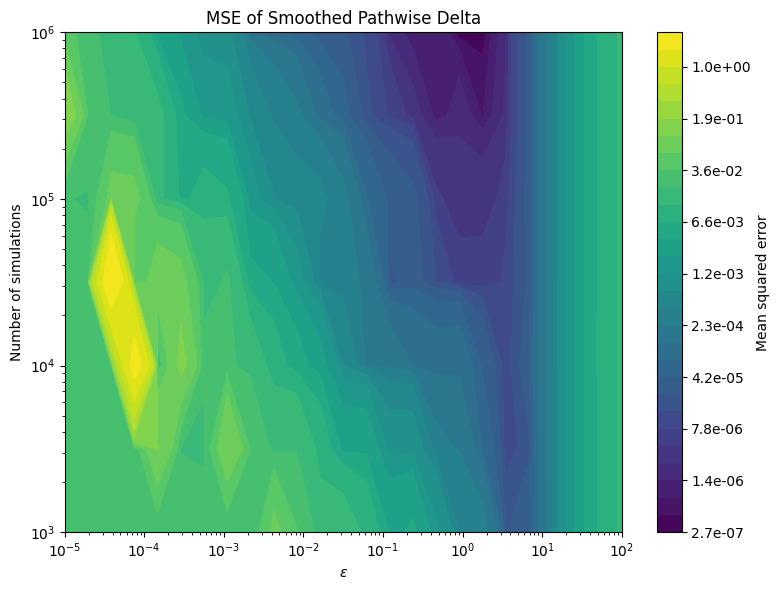

In [20]:
EPSILON, REPS = np.meshgrid(
    epsilon_values,
    reps_values,
    indexing="ij"
)

mse_min = pw_mse[pw_mse > 0].min()
mse_max = pw_mse.max()
levels = np.geomspace(mse_min, mse_max, 30)

plt.figure(figsize=(8, 6))

contour = plt.contourf(EPSILON,REPS,pw_mse,levels=levels,norm=LogNorm(vmin=mse_min, vmax=mse_max))

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"Number of simulations")
plt.title("MSE of Smoothed Pathwise Delta")

cbar = plt.colorbar(contour, format="%.1e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

We observe that, in general, a greater number of simulations results in a smaller optimal value of $\varepsilon$. The overall pattern is similar to Finite Differences case, and in fact the MSE of the above approximation is given by 

$$
\operatorname{MSE}\left(\widehat{\Delta}_{\varepsilon}\right)
\approx
A\varepsilon^4+\frac{B}{N\varepsilon},
$$

where the first term represents squared smoothing bias and the second represents Monte Carlo variance. 

Consequently, minimising with respect to $\varepsilon$ gives

$$
\varepsilon_{\mathrm{opt}}(N)
=
\left(\frac{B}{4A}\right)^{1/5}N^{-1/5}
.
$$

See the 01_estimator_theory.ipynb notebook for a derivation of this result.

We use this result to fit a surface to the above data and derive an optimal-$\varepsilon$ function taking $N$ as its only variable.

In [21]:
# Grid of values
epsilon_values_fit = np.logspace(-1, 1, 12)
reps_values_fit = np.unique(np.logspace(3, 5, 8).round().astype(int))

trials = 10

pw_mse_fit = np.empty((len(epsilon_values_fit), len(reps_values_fit)))

for i, epsilon_i in enumerate(epsilon_values_fit):
    for j, reps_j in enumerate(reps_values_fit):
        squared_errors = np.empty(trials)

        for trial in range(trials):
            delta_pw = pathwise.mc_digital_call_delta_pw_estimate(s, K, Q, T, r, vol, reps_j, epsilon_i)
            squared_errors[trial] = (delta_pw - real_delta)**2

        pw_mse_fit[i, j] = np.mean(squared_errors)

EPS, N = np.meshgrid(
    epsilon_values_fit,
    reps_values_fit,
    indexing="ij"
)

x_data = np.vstack([N.ravel(),EPS.ravel()])

y_data = pw_mse_fit.ravel()

def pw_mse_model(x, A, B):
    N, epsilon = x
    return A * epsilon**4 + B / (N * epsilon)

parameters, covariance = curve_fit(
    pw_mse_model,
    x_data,
    y_data,
    p0=(1e-8, 10),
    bounds=(0, np.inf)
)

A_hat_pw, B_hat_pw = parameters

print(f"Estimated A = {A_hat_pw:.6e}")
print(f"Estimated B = {B_hat_pw:.6e}")

Estimated A = 1.270191e-08
Estimated B = 3.379010e-01


In [22]:
# Optimal epsilon as a function of N (according to theory)
def epsilon_opt_pw(N):
    return ((B_hat_pw/(4*A_hat_pw))**(1/5))*(N**(-1/5))

In [23]:
# Print optimal values
print(f"Optimal epsilon for N = 1,000 : {epsilon_opt_pw(1_000)}")
print(f"Optimal epsilon for N = 10,000 : {epsilon_opt_pw(10_000)}")
print(f"Optimal epsilon for N = 100,000 : {epsilon_opt_pw(100_000)}")
print(f"Optimal epsilon for N = 1,000,000 : {epsilon_opt_pw(1_000_000)}")

Optimal epsilon for N = 1,000 : 5.815300073269993
Optimal epsilon for N = 10,000 : 3.669206291585908
Optimal epsilon for N = 100,000 : 2.315112658089062
Optimal epsilon for N = 1,000,000 : 1.460737334920356


Next, we investigate the MSE of the Pathwise Differentiation method for the four different optimal ($\varepsilon$-$N$) pairs above under varying moneyness and volatility. Notice that the optimal pairs estimated depend, in fact, on the moneyness and volatility too, so the results below are not the most optimal for every parameter combination. Nonetheless, we take the optimal pairs for moneyness $= 1$ and vol $= 0.25$ as approximate midpoints that serve the entire grid.

In [24]:
# Moneyness-volatility grid
moneyness_values = np.linspace(0.7,1.3,25)
vol_values = np.linspace(0.1,0.6,25)

# Optimal epsilon-reps pairs
reps_values = [1_000,10_000,100_000,1_000_000]
epsilon_reps_pairs = [(reps,epsilon_opt_pw(reps)) for reps in reps_values]

display(pd.DataFrame(epsilon_reps_pairs,columns=["reps","optimal epsilon"]))

trials = 5
pw_mse_results = {}

for reps,epsilon in epsilon_reps_pairs:
    pw_mse = np.empty((len(moneyness_values),len(vol_values)))

    for i,moneyness_i in enumerate(moneyness_values):
        s_i = K * moneyness_i

        for j,vol_j in enumerate(vol_values):
            d2 = (np.log(moneyness_i)+(r-vol_j**2/2)*T)/(vol_j*np.sqrt(T))
            real_delta = Q*np.exp(-r*T)*norm.pdf(d2)/(s_i*vol_j*np.sqrt(T))

            trial_errors = np.empty(trials)

            for trial in range(trials):
                delta_pw = pathwise.mc_digital_call_delta_pw_estimate(s_i,K,Q,T,r,vol_j,reps,epsilon)
                trial_errors[trial] = (delta_pw-real_delta)**2

            pw_mse[i,j] = np.mean(trial_errors)

    pw_mse_results[reps] = {"epsilon":epsilon,"mse":pw_mse}

    pw_error_table = pd.DataFrame(pw_mse,index=moneyness_values,columns=vol_values)
    pw_error_table.index.name = "moneyness"
    pw_error_table.columns.name = "vol"

    print(f"reps = {reps:,}, optimal epsilon = {epsilon:.4f}")
    display(pw_error_table)

,reps,optimal epsilon
0,1000,5.815300
1,10000,3.669206
2,100000,2.315113
3,1000000,1.460737


reps = 1,000, optimal epsilon = 5.8153


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000111,0.000202,0.000148,0.000072,0.000110,0.000101,0.000060,0.000035,0.000037,0.000046,...,0.000045,0.000131,0.000080,0.000057,0.000019,0.000011,0.000042,0.000025,0.000018,0.000069
0.725,0.000299,0.000360,0.000132,0.000127,0.000042,0.000102,0.000034,0.000055,0.000019,0.000030,...,0.000020,0.000042,0.000014,0.000040,0.000023,0.000088,0.000034,0.000014,0.000029,0.000021
0.750,0.000632,0.000357,0.000077,0.000062,0.000019,0.000086,0.000086,0.000071,0.000016,0.000084,...,0.000024,0.000052,0.000154,0.000014,0.000023,0.000070,0.000023,0.000056,0.000031,0.000025
0.775,0.001069,0.000463,0.000100,0.000215,0.000080,0.000085,0.000129,0.000055,0.000056,0.000035,...,0.000055,0.000034,0.000067,0.000032,0.000034,0.000018,0.000075,0.000099,0.000035,0.000048
0.800,0.000982,0.000308,0.000107,0.000035,0.000081,0.000111,0.000088,0.000008,0.000034,0.000024,...,0.000037,0.000080,0.000086,0.000088,0.000006,0.000021,0.000013,0.000032,0.000025,0.000061
0.825,0.000550,0.000138,0.000093,0.000060,0.000121,0.000102,0.000024,0.000083,0.000018,0.000027,...,0.000045,0.000118,0.000053,0.000063,0.000027,0.000009,0.000053,0.000026,0.000019,0.000037
0.850,0.000125,0.000068,0.000120,0.000027,0.000093,0.000042,0.000056,0.000032,0.000073,0.000004,...,0.000085,0.000044,0.000022,0.000029,0.000017,0.000031,0.000077,0.000018,0.000096,0.000033
0.875,0.000155,0.000220,0.000163,0.000152,0.000052,0.000042,0.000039,0.000051,0.000162,0.000009,...,0.000008,0.000068,0.000037,0.000005,0.000064,0.000074,0.000016,0.000030,0.000017,0.000067
0.900,0.001191,0.000714,0.000423,0.000300,0.000139,0.000107,0.000060,0.000062,0.000030,0.000038,...,0.000080,0.000021,0.000016,0.000014,0.000049,0.000083,0.000061,0.000029,0.000025,0.000048


reps = 10,000, optimal epsilon = 3.6692


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000010,0.000021,0.000019,0.000028,0.000018,0.000014,1.781674e-05,0.000004,0.000005,1.093421e-06,...,0.000018,0.000012,0.000003,0.000009,6.751874e-06,9.535719e-06,1.755690e-06,4.079899e-06,1.296650e-05,4.786570e-06
0.725,0.000041,0.000062,0.000028,0.000035,0.000013,0.000034,2.037331e-05,0.000004,0.000004,1.961462e-05,...,0.000003,0.000010,0.000005,0.000009,5.916705e-06,4.829007e-06,9.003374e-06,5.675622e-06,6.721601e-06,1.417995e-05
0.750,0.000103,0.000081,0.000035,0.000036,0.000013,0.000006,7.967174e-06,0.000009,0.000027,1.223791e-05,...,0.000022,0.000003,0.000010,0.000019,2.048324e-05,5.900704e-06,1.277938e-06,5.538393e-06,9.880949e-06,5.760915e-06
0.775,0.000147,0.000092,0.000024,0.000013,0.000013,0.000027,3.802692e-06,0.000006,0.000010,3.706211e-05,...,0.000004,0.000010,0.000020,0.000012,1.387637e-05,5.161348e-06,3.050786e-06,3.446774e-06,2.119109e-05,8.094151e-06
0.800,0.000184,0.000039,0.000047,0.000003,0.000019,0.000011,3.314505e-05,0.000007,0.000012,2.773622e-05,...,0.000004,0.000005,0.000009,0.000006,3.498945e-06,6.367816e-06,1.018463e-05,6.521303e-06,1.501207e-06,4.894243e-06
0.825,0.000157,0.000032,0.000010,0.000008,0.000021,0.000008,1.284615e-05,0.000008,0.000017,3.198231e-05,...,0.000003,0.000003,0.000009,0.000008,4.622851e-06,4.713787e-06,7.780100e-06,7.835094e-06,7.532954e-06,2.117238e-06
0.850,0.000058,0.000004,0.000010,0.000029,0.000034,0.000008,6.922566e-06,0.000011,0.000004,6.005174e-06,...,0.000002,0.000002,0.000003,0.000004,3.798484e-06,5.837222e-06,6.630473e-06,3.452995e-06,2.530628e-06,6.584531e-06
0.875,0.000047,0.000047,0.000032,0.000028,0.000030,0.000015,2.476974e-05,0.000014,0.000016,4.964401e-06,...,0.000008,0.000003,0.000002,0.000007,1.822265e-06,1.243770e-05,4.826258e-06,2.024431e-06,9.447708e-06,5.454296e-06
0.900,0.000278,0.000124,0.000065,0.000079,0.000007,0.000016,9.191276e-06,0.000002,0.000014,1.453729e-05,...,0.000012,0.000013,0.000017,0.000005,8.574888e-06,2.384339e-05,3.954277e-06,9.724631e-06,1.669589e-06,7.386279e-06


reps = 100,000, optimal epsilon = 2.3151


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,1.430900e-06,3.646568e-06,4.330554e-06,5.092400e-06,9.118254e-07,2.066614e-06,1.287570e-06,1.450541e-06,7.898165e-07,6.351487e-07,...,2.867147e-07,3.759344e-06,1.510915e-06,2.225097e-07,9.796699e-07,1.749665e-06,1.013672e-06,1.479845e-06,6.757725e-07,5.497093e-07
0.725,5.097745e-06,7.976656e-06,4.206784e-06,2.941353e-06,6.204834e-07,3.321888e-07,3.033505e-06,1.310904e-06,1.117036e-06,4.264658e-07,...,8.198303e-07,9.515751e-07,5.558232e-07,1.288441e-06,3.300573e-06,7.199842e-07,5.704171e-07,1.409432e-06,7.354131e-07,1.161205e-07
0.750,1.445578e-05,1.442499e-05,6.014374e-06,3.992716e-06,5.046591e-06,2.249157e-07,1.017049e-06,4.408715e-07,2.496591e-06,8.756576e-07,...,7.630230e-07,1.758176e-06,5.163695e-07,8.527218e-07,3.214704e-07,3.021105e-07,6.124601e-07,7.239040e-07,1.037079e-06,5.266576e-07
0.775,2.719576e-05,1.411304e-05,6.464299e-06,4.262413e-06,2.444676e-06,1.528814e-06,8.551591e-07,2.680143e-06,1.292041e-06,1.616143e-06,...,1.156908e-06,8.560556e-07,4.946558e-07,2.672819e-06,3.338187e-06,5.810674e-08,8.962370e-07,6.990741e-07,7.794515e-07,1.623478e-06
0.800,3.302557e-05,8.414881e-06,3.703897e-06,1.516970e-06,4.633764e-06,1.426500e-06,1.513193e-06,8.042682e-07,1.197798e-06,1.151191e-06,...,6.171859e-07,1.930603e-06,2.418919e-06,8.223329e-07,4.395769e-07,7.350005e-07,2.654732e-06,8.204987e-07,9.432316e-07,2.193852e-06
0.825,3.335987e-05,3.924414e-06,1.262116e-06,1.229064e-06,2.618728e-06,1.774162e-06,2.376065e-06,7.789035e-07,1.112049e-06,3.838517e-06,...,2.327550e-07,1.121972e-06,2.862693e-06,8.414716e-08,2.162242e-06,7.336912e-07,1.077204e-06,7.153011e-07,2.283141e-07,8.486175e-07
0.850,1.142137e-05,3.014360e-06,2.150459e-06,2.630039e-06,3.537101e-06,4.096213e-06,2.452090e-06,7.800019e-07,2.192137e-06,3.054387e-07,...,1.008615e-07,7.131668e-07,6.957444e-07,1.302760e-06,9.546825e-07,1.770129e-06,7.976803e-07,2.836308e-07,7.341902e-07,8.249051e-07
0.875,1.152252e-06,2.489888e-07,4.506907e-06,1.643169e-06,6.151335e-06,1.012229e-06,3.367317e-06,7.787269e-07,2.614338e-06,1.446359e-06,...,1.569016e-06,4.237051e-06,7.651356e-07,1.226881e-06,1.009898e-06,3.060286e-07,1.285338e-06,4.414359e-07,1.556050e-06,3.735200e-07
0.900,1.715671e-05,2.585604e-05,3.715480e-06,1.021808e-05,1.555959e-06,3.684157e-06,1.910423e-06,3.754536e-07,1.499445e-06,2.065427e-06,...,2.620487e-07,6.635964e-07,1.572669e-06,4.216262e-07,4.133443e-07,2.835447e-07,3.522853e-07,5.486464e-07,1.099552e-07,1.227109e-06


reps = 1,000,000, optimal epsilon = 1.4607


vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,2.305561e-07,4.217329e-07,5.464889e-07,6.359820e-07,2.476504e-07,3.984484e-07,9.399265e-08,1.363742e-07,3.522108e-07,3.840130e-07,...,6.099150e-08,2.334381e-07,5.802561e-08,3.420215e-08,9.323370e-08,2.009113e-07,1.532016e-07,1.738317e-07,8.265609e-08,6.101934e-08
0.725,8.347886e-07,1.426153e-06,1.166931e-06,5.983208e-07,5.214961e-07,2.122904e-07,6.434763e-07,2.752730e-07,8.840073e-08,1.945013e-07,...,2.450901e-07,2.474412e-07,2.654138e-07,1.523544e-07,1.773893e-07,3.134240e-07,9.360539e-08,4.565480e-07,9.763779e-08,2.411546e-07
0.750,1.972156e-06,2.214408e-06,7.667386e-07,4.049603e-07,3.495315e-07,2.584914e-07,4.396902e-08,2.031166e-07,2.290636e-07,5.854028e-07,...,2.655322e-07,2.539430e-07,4.263805e-08,1.842263e-07,2.335552e-07,2.053129e-07,9.582721e-08,3.324570e-07,6.009993e-08,2.263955e-07
0.775,4.454794e-06,1.926647e-06,2.104923e-06,2.347337e-07,4.058630e-07,7.653221e-08,1.356260e-07,2.634722e-07,3.667919e-07,3.009934e-07,...,2.598627e-07,1.674183e-07,4.185017e-07,1.472506e-07,2.060931e-07,1.565531e-07,1.340248e-07,4.479205e-08,1.932609e-07,1.571668e-07
0.800,6.618450e-06,1.900447e-06,5.626067e-07,2.235502e-07,4.594856e-07,1.242561e-07,3.049927e-07,3.015288e-07,3.895668e-07,2.377596e-07,...,8.106363e-08,2.037456e-07,3.564171e-07,5.421370e-08,2.616818e-07,1.047993e-07,2.955608e-07,2.982002e-07,3.641257e-08,1.342219e-07
0.825,5.697274e-06,1.060959e-06,4.076686e-07,1.705363e-07,3.783745e-07,1.429303e-07,2.663972e-07,6.587737e-07,5.127219e-07,1.217470e-07,...,7.851759e-08,1.711562e-07,4.671049e-07,1.034275e-07,1.565885e-07,9.003380e-08,7.690134e-08,1.299463e-07,1.215691e-07,8.686897e-08
0.850,5.591616e-07,4.040917e-07,8.117317e-07,3.518105e-07,5.712285e-07,2.446592e-07,4.222628e-07,1.237990e-07,8.008663e-07,4.444333e-07,...,1.016537e-07,1.160103e-07,1.163716e-07,1.697122e-07,2.326498e-07,2.896847e-07,8.360151e-08,5.362252e-08,1.890623e-07,2.696121e-07
0.875,6.828805e-07,4.484053e-07,1.976354e-07,2.829009e-07,6.274682e-07,5.844404e-07,1.119656e-07,9.260920e-08,4.080818e-07,2.509555e-07,...,4.956152e-08,3.072715e-07,2.523540e-07,2.885171e-07,9.776960e-08,2.402660e-07,3.290768e-08,1.272975e-07,1.715237e-07,9.741158e-08
0.900,5.165695e-06,2.401770e-06,1.882745e-06,1.520628e-06,4.341267e-07,3.774437e-07,4.259398e-08,1.969751e-07,2.262435e-07,3.990494e-07,...,6.675431e-07,7.479091e-08,2.614066e-08,1.289667e-07,2.756764e-07,2.317775e-07,2.937407e-07,1.593268e-08,1.484031e-07,2.555319e-07


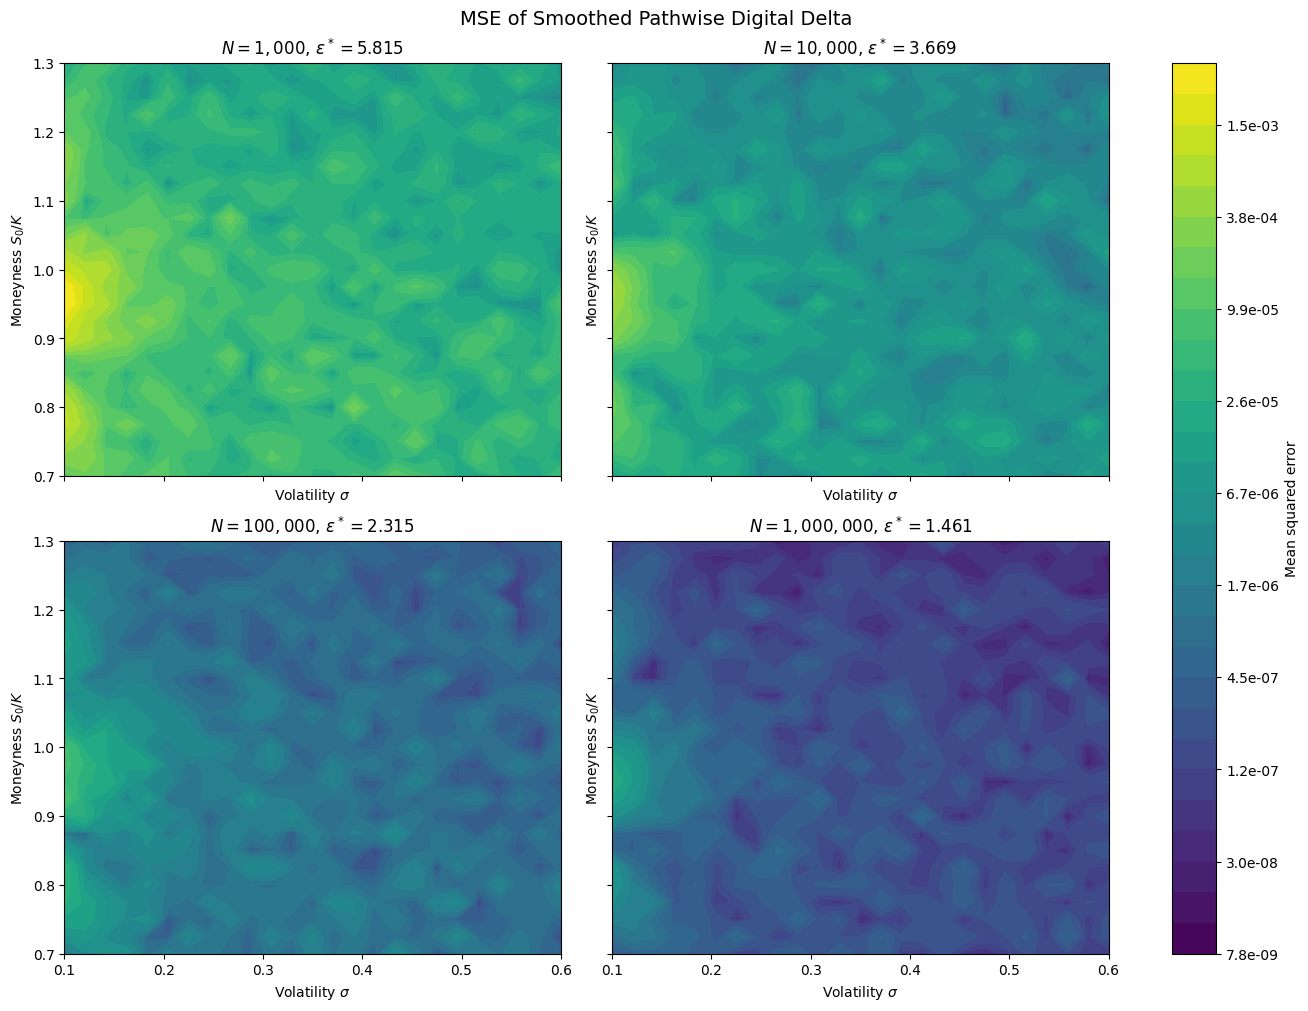

In [25]:
VOL,MONEYNESS = np.meshgrid(vol_values,moneyness_values)

all_mse = np.concatenate([result["mse"].ravel() for result in pw_mse_results.values()])
positive_mse = all_mse[all_mse > 0]

mse_min = positive_mse.min()
mse_max = positive_mse.max()

levels = np.geomspace(mse_min,mse_max,30)
normalisation = LogNorm(vmin=mse_min,vmax=mse_max)

fig,axes = plt.subplots(2,2,figsize=(13,10),sharex=True,sharey=True,constrained_layout=True)

for ax,(reps,result) in zip(axes.ravel(),pw_mse_results.items()):
    epsilon = result["epsilon"]
    pw_mse = result["mse"]

    contour = ax.contourf(VOL,MONEYNESS,pw_mse,levels=levels,norm=normalisation)

    ax.set_xlabel(r"Volatility $\sigma$")
    ax.set_ylabel(r"Moneyness $S_0/K$")
    ax.set_title(rf"$N={reps:,}$, $\varepsilon^*={epsilon:.3f}$")

cbar = fig.colorbar(contour,ax=axes.ravel().tolist(),format="%.1e")
cbar.set_label("Mean squared error")

fig.suptitle("MSE of Smoothed Pathwise Digital Delta",fontsize=14)

plt.show()

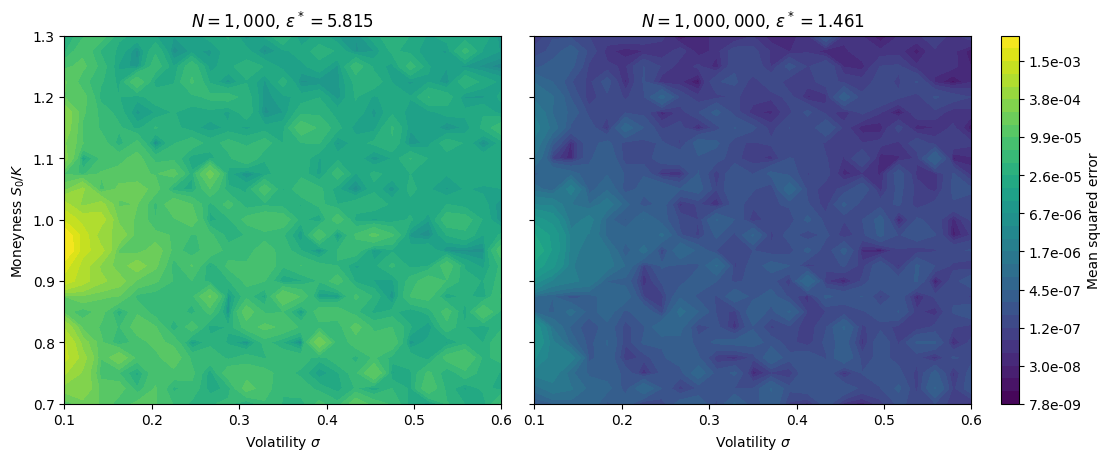

In [26]:
# Select the two endpoint cases
selected_reps = [1_000, 1_000_000]

VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

# Shared logarithmic colour scale across both panels
selected_mse = np.concatenate([
    pw_mse_results[reps]["mse"].ravel()
    for reps in selected_reps
])

positive_mse = selected_mse[selected_mse > 0]

mse_min = positive_mse.min()
mse_max = positive_mse.max()

levels = np.geomspace(mse_min, mse_max, 30)
normalisation = LogNorm(vmin=mse_min, vmax=mse_max)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, reps in zip(axes, selected_reps):
    result = pw_mse_results[reps]
    epsilon = result["epsilon"]
    mse = result["mse"]

    contour = ax.contourf(VOL,MONEYNESS,mse,levels=levels,norm=normalisation)

    ax.set_xlabel(r"Volatility $\sigma$")
    ax.set_title(
        rf"$N={reps:,}$, $\varepsilon^*={epsilon:.3f}$"
    )

axes[0].set_ylabel(r"Moneyness $S_0/K$")

cbar = fig.colorbar(
    contour,
    ax=axes.tolist(),
    format="%.1e",
    pad=0.02
)
cbar.set_label("Mean squared error")

plt.show()

We observe, as expected, that the MSE decreases as we increase the number of reps $N$. Across all plots, MSE is maximum around for low-volatility, ATM options. This makes sense, as Delta is largest near the discontinuity and consequently the absolute error of the approximation should be expected to be largest too. 

## Likelihood-Ratio

We now investigate the Likelihood-Ratio method for the approximation of the Delta of the Digital call option. Unlike the Pathwise Differentiation method, this does not require any modifications or approximations to be conducted; the method can be applied as usual as it does not require the payoff function to be continuous.

Using the same Digital call used at the beginning of the notebook, we consider the MSE of the LR Delta estimation across the usual moneyness-volatility grid. We fix $N = 1,000$ as in this case the reps predictably reduce the MSE as they become larger without depending on other parameters (unlike the Pathwise Differentiation method above).

In [27]:
# Values to investigate
moneyness_values = np.linspace(0.7, 1.3, 25)
vol_values = np.linspace(0.10, 0.60, 25)

In [28]:
trials = 100
reps = 1_000

# Rows correspond to moneyness, columns correspond to vol
lr_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, vol_j in enumerate(vol_values):
        d2 = (np.log(s_i/K) + (r - 0.5*(vol_j**2))*T) / (vol_j * np.sqrt(T))
        real_delta = (Q * np.exp(-r*T) * norm.pdf(d2)) / (s_i * vol_j * np.sqrt(T))
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_lr = likelihood_ratio.mc_digital_call_delta_lr_estimate(s_i,K,Q,T,r,vol_j,reps)
            trial_errors[trial] = (delta_lr - real_delta)**2
        lr_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
lr_error_table = pd.DataFrame(lr_mse, index=moneyness_values, columns=vol_values)

lr_error_table.index.name = "moneyness"
lr_error_table.columns.name = "vol"

display(lr_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000018,0.000045,0.000076,0.000109,0.000103,0.000111,0.000093,0.000094,0.000081,0.000067,...,0.000034,0.000043,0.000030,0.000040,0.000026,0.000031,0.000025,0.000021,0.000019,0.000018
0.725,0.000036,0.000098,0.000081,0.000097,0.000109,0.000094,0.000102,0.000104,0.000058,0.000063,...,0.000040,0.000034,0.000022,0.000025,0.000024,0.000023,0.000022,0.000019,0.000018,0.000018
0.750,0.000073,0.000109,0.000153,0.000132,0.000125,0.000126,0.000111,0.000088,0.000083,0.000052,...,0.000035,0.000030,0.000020,0.000020,0.000027,0.000026,0.000024,0.000019,0.000015,0.000015
0.775,0.000194,0.000195,0.000204,0.000108,0.000146,0.000093,0.000120,0.000093,0.000081,0.000052,...,0.000025,0.000024,0.000023,0.000022,0.000032,0.000016,0.000021,0.000016,0.000015,0.000012
0.800,0.000264,0.000211,0.000215,0.000152,0.000118,0.000113,0.000083,0.000073,0.000083,0.000052,...,0.000023,0.000029,0.000023,0.000022,0.000019,0.000020,0.000017,0.000018,0.000016,0.000012
0.825,0.000270,0.000280,0.000259,0.000156,0.000125,0.000118,0.000095,0.000080,0.000081,0.000055,...,0.000027,0.000029,0.000026,0.000021,0.000019,0.000017,0.000015,0.000016,0.000015,0.000013
0.850,0.000358,0.000289,0.000263,0.000168,0.000138,0.000080,0.000107,0.000083,0.000068,0.000067,...,0.000027,0.000015,0.000027,0.000022,0.000020,0.000018,0.000014,0.000015,0.000014,0.000012
0.875,0.000426,0.000332,0.000192,0.000179,0.000123,0.000098,0.000056,0.000082,0.000049,0.000053,...,0.000024,0.000021,0.000023,0.000016,0.000015,0.000014,0.000015,0.000012,0.000011,0.000014
0.900,0.000301,0.000243,0.000168,0.000145,0.000097,0.000088,0.000067,0.000065,0.000054,0.000047,...,0.000026,0.000023,0.000019,0.000019,0.000019,0.000014,0.000011,0.000012,0.000010,0.000011


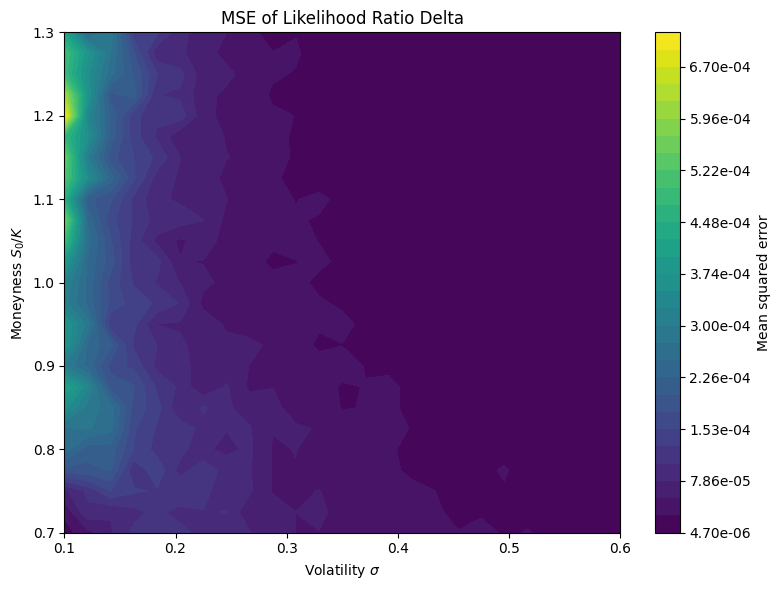

In [29]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Linear contour levels and linear axes
levels = np.linspace(lr_mse.min(), lr_mse.max(), 30)

contour = plt.contourf(VOL,MONEYNESS,lr_mse,levels=levels)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("MSE of Likelihood Ratio Delta")

cbar = plt.colorbar(contour, format="%.2e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

We observe clearly that the low-volatility region produces a greater MSE. This is explained, once again, by the $\sigma^{-1}$ factor in the score of the LR Delta estimator, which increases variance as it becomes smaller. Additionally, moneyness seems to have no relevant effect on the MSE.

We attempt to decrease the error even further by implementing payoff centring as done previously for Europeans and Asians. We have that

$$
c^*=\frac{\mathbb{E}[HZ^2]}{\mathbb{E}[Z^2]},
$$

where $H=\mathbf{1}_{\{S_T>K\}}$. The centred LR estimator is then as usual

$$
\widehat{\Delta}_{LR,c}
=
\frac{e^{-rT}}{N}
\sum_{i=1}^N
(H_i-c^*)
\frac{Z_i}{S_0\sigma\sqrt{T}}.
$$

We investigate the MSE on the same grid.

In [30]:
# Define function to estimate optimal value of c
def optimal_c_digital(s,K,Q,T,r,vol,reps):
    Z = np.random.standard_normal(reps)
    paths = path_simulator.one_step_paths(s,T,r,vol,reps,Z)
    call_payoffs = payoffs.digital_call_payoff(paths,K,Q)
    H = np.exp(-r*T) * np.where(call_payoffs > 0, call_payoffs, 0)
    c = np.sum(H * Z**2) / np.sum(Z**2)
    return c

In [31]:
trials = 100
reps = 1_000

# Rows correspond to moneyness, columns correspond to vol
lr_centred_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, vol_j in enumerate(vol_values):
        d2 = (np.log(s_i/K) + (r - 0.5*(vol_j**2))*T) / (vol_j * np.sqrt(T))
        real_delta = (Q * np.exp(-r*T) * norm.pdf(d2)) / (s_i * vol_j * np.sqrt(T))
        c = optimal_c_digital(s_i,K,Q,T,r,vol_j,reps)
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_lr = likelihood_ratio.mc_digital_call_delta_lr_centred_estimate(s_i,K,Q,T,r,vol_j,reps,c)
            trial_errors[trial] = (delta_lr - real_delta)**2
        lr_centred_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
lr_centred_error_table = pd.DataFrame(lr_centred_mse, index=moneyness_values, columns=vol_values)

lr_centred_error_table.index.name = "moneyness"
lr_centred_error_table.columns.name = "vol"

display(lr_centred_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000020,0.000048,0.000073,0.000086,0.000081,0.000067,0.000072,0.000052,0.000050,0.000046,...,0.000018,0.000017,0.000017,0.000011,0.000015,0.000013,0.000011,0.000010,0.000010,0.000007
0.725,0.000034,0.000086,0.000102,0.000089,0.000107,0.000081,0.000063,0.000063,0.000047,0.000041,...,0.000021,0.000015,0.000013,0.000014,0.000012,0.000011,0.000009,0.000009,0.000009,0.000007
0.750,0.000072,0.000133,0.000140,0.000090,0.000090,0.000086,0.000047,0.000054,0.000038,0.000034,...,0.000016,0.000014,0.000011,0.000014,0.000011,0.000010,0.000009,0.000008,0.000006,0.000006
0.775,0.000137,0.000123,0.000140,0.000105,0.000081,0.000069,0.000043,0.000051,0.000035,0.000027,...,0.000018,0.000010,0.000012,0.000009,0.000010,0.000008,0.000008,0.000007,0.000007,0.000006
0.800,0.000203,0.000125,0.000188,0.000097,0.000084,0.000063,0.000057,0.000039,0.000034,0.000033,...,0.000014,0.000013,0.000012,0.000009,0.000008,0.000009,0.000007,0.000006,0.000007,0.000005
0.825,0.000206,0.000213,0.000107,0.000087,0.000071,0.000046,0.000041,0.000037,0.000022,0.000025,...,0.000009,0.000008,0.000008,0.000007,0.000005,0.000007,0.000007,0.000004,0.000006,0.000006
0.850,0.000221,0.000104,0.000104,0.000069,0.000057,0.000039,0.000039,0.000030,0.000027,0.000020,...,0.000009,0.000010,0.000008,0.000008,0.000007,0.000004,0.000005,0.000006,0.000005,0.000004
0.875,0.000224,0.000110,0.000076,0.000056,0.000048,0.000047,0.000028,0.000025,0.000021,0.000016,...,0.000009,0.000008,0.000008,0.000007,0.000004,0.000005,0.000004,0.000005,0.000004,0.000004
0.900,0.000163,0.000122,0.000074,0.000058,0.000031,0.000028,0.000023,0.000020,0.000014,0.000015,...,0.000007,0.000006,0.000006,0.000005,0.000006,0.000004,0.000004,0.000004,0.000004,0.000003


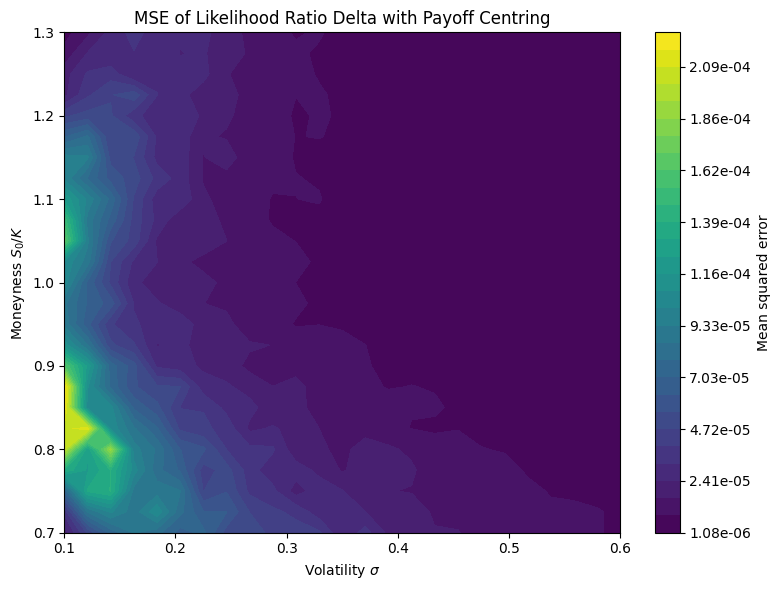

In [32]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Linear contour levels and linear axes
levels = np.linspace(lr_centred_mse.min(), lr_centred_mse.max(), 30)

contour = plt.contourf(VOL,MONEYNESS,lr_centred_mse,levels=levels)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("MSE of Likelihood Ratio Delta with Payoff Centring")

cbar = plt.colorbar(contour, format="%.2e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

Clearly, payoff centring reduces the MSE across the entire grid, although the general pattern showing larger MSE values in the low-volatility region persists. In order to understand the benefits of this variance-reduction method better, we plot the ratio $\frac{\operatorname{MSE}(\text{LR with centring})}{\operatorname{MSE}(\text{LR without centring})}$ below.

In [33]:
# Rows correspond to moneyness, columns correspond to vol
lr_mse_ratio = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    for j,vol_j in enumerate(vol_values):
        ratio = lr_centred_mse[i,j]/lr_mse[i,j]
        lr_mse_ratio[i,j] = ratio

# Convert the results into a labelled table
lr_mse_ratio_error_table = pd.DataFrame(lr_mse_ratio, index=moneyness_values, columns=vol_values)

lr_mse_ratio_error_table.index.name = "moneyness"
lr_mse_ratio_error_table.columns.name = "vol"

display(lr_mse_ratio_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,1.104761,1.074571,0.961541,0.788883,0.784285,0.601735,0.776130,0.548437,0.623252,0.678026,...,0.509717,0.403632,0.559276,0.285406,0.580868,0.437306,0.463733,0.464070,0.513404,0.370584
0.725,0.956147,0.877487,1.268697,0.922796,0.975413,0.855364,0.616051,0.607215,0.807698,0.656292,...,0.522558,0.445190,0.598463,0.580281,0.496781,0.478645,0.419032,0.489747,0.510691,0.412094
0.750,0.988900,1.219605,0.914119,0.685408,0.720351,0.680028,0.422627,0.622224,0.456123,0.651282,...,0.451482,0.490398,0.580443,0.686653,0.395405,0.376734,0.357944,0.433161,0.412314,0.408156
0.775,0.706648,0.629662,0.684984,0.971195,0.555113,0.746499,0.361671,0.544520,0.437858,0.513124,...,0.736412,0.425511,0.506928,0.428042,0.321349,0.527930,0.383720,0.440680,0.436988,0.443259
0.800,0.770609,0.592798,0.873876,0.638884,0.711302,0.553863,0.680398,0.540589,0.408063,0.634081,...,0.613785,0.432937,0.531616,0.403852,0.450496,0.426106,0.383248,0.352065,0.407761,0.404934
0.825,0.763527,0.763121,0.411689,0.557914,0.569642,0.387022,0.432031,0.462932,0.278331,0.455285,...,0.323157,0.261444,0.326433,0.359840,0.256944,0.388973,0.483776,0.261278,0.385058,0.418918
0.850,0.616353,0.360771,0.395579,0.409724,0.414632,0.492516,0.363679,0.357554,0.393198,0.290811,...,0.330772,0.623695,0.283925,0.392162,0.359224,0.250387,0.378194,0.369326,0.381546,0.309631
0.875,0.526005,0.329828,0.395313,0.312725,0.395251,0.482393,0.495689,0.309961,0.431144,0.310854,...,0.368092,0.398738,0.362568,0.469008,0.290882,0.370999,0.290216,0.464181,0.316053,0.314368
0.900,0.542564,0.499918,0.443238,0.399700,0.315822,0.315837,0.338611,0.315193,0.267821,0.323258,...,0.271340,0.280360,0.321869,0.276848,0.344608,0.276477,0.387874,0.322025,0.368638,0.241725


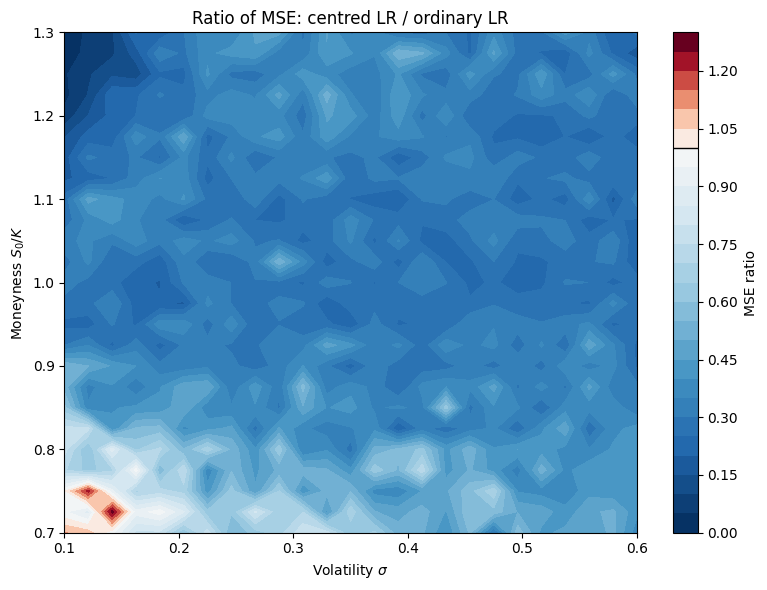

In [34]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Centre the colormap at ratio = 1
map_norm = TwoSlopeNorm(
    vmin=lr_mse_ratio.min(),
    vcenter=1.0,
    vmax=lr_mse_ratio.max()
)

contour = plt.contourf(VOL,MONEYNESS,lr_mse_ratio,levels=30,cmap="RdBu_r",norm=map_norm)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("Ratio of MSE: centred LR / ordinary LR")

cbar = plt.colorbar(contour, format="%.2f")
cbar.set_label("MSE ratio")
cbar.ax.axhline(1.0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

We observe clear improvements across the entire grid. In particular, high moneyness, low volatility options present a much more accurate Delta approximation, while a few low moneyness, low volatility options present a slightly worse Delta, in a similar manner to the previous options investigated. In general, the above analysis strongly supports the use of payoff centring, so long as the additional computational effort remains reasonable, which appears to be the case given the identical runtime for the computation of both MSE tables up to decimal second precision.

To finish this Notebook, we do a comparative analysis of the three methods investigated for Digital calls. We choose the best variant of each method (considering both MSE of approximation and runtime), namely Central Differences with CRN, Pathwise Differentiation, and Likelihood-Ratio with Payoff Centring, and compute the metrics MSE and MSE x Runtime for each.

We fix $N = 1,000$ as the effect of increasing the value of reps is expected to be homogeneous across the different methods, and consider optimal parameters for each method, where appropriate. Since the optimal step size $h$ for the Central Difference method and the optimal $\varepsilon$ for the Pathwise Differentiation method depend on moneyness and volatility, we fix the optimal ratio $h/S_0$ and ${\varepsilon}/S_0$ computed for an option at the midpoint of the moneyness-volatility grid (moneyness $= 1$ and $\sigma = 0.35$).

In [35]:
# Define optimal ratios found empirically through the above investigation
relative_h = 0.050
relative_epsilon = 0.038

In [36]:
trials = 100
reps = 1_000
pilot_reps = 1_000

shape = (len(moneyness_values), len(vol_values))

# MSE arrays
cd_crn_mse = np.empty(shape)
pw_mse = np.empty(shape)
lr_centred_mse = np.empty(shape)

# Estimator runtime arrays
cd_crn_runtime = np.empty(shape)
pw_runtime = np.empty(shape)
lr_centred_runtime = np.empty(shape)

# Separate runtime required to estimate c
lr_c_runtime = np.empty(shape)

for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    h_i = relative_h * s_i
    epsilon_i = relative_epsilon * s_i

    for j, vol_j in enumerate(vol_values):
        d2 = (np.log(s_i/K) + (r - 0.5*(vol_j**2))*T) / (vol_j * np.sqrt(T))
        real_delta = (Q * np.exp(-r*T) * norm.pdf(d2)) / (s_i * vol_j * np.sqrt(T))

        start = time.perf_counter()
        c_ij = optimal_c_digital(s_i, K, Q, T, r, vol_j, pilot_reps)
        lr_c_runtime[i, j] = time.perf_counter() - start

        cd_trial_errors = np.empty(trials)
        pw_trial_errors = np.empty(trials)
        lr_trial_errors = np.empty(trials)

        cd_trial_runtimes = np.empty(trials)
        pw_trial_runtimes = np.empty(trials)
        lr_trial_runtimes = np.empty(trials)

        for trial in range(trials):
            start = time.perf_counter()
            delta_cd_crn = finite_difference.mc_digital_call_delta_cd_estimate_crn(s_i, K, Q, T, r, vol_j, reps, h_i)
            cd_trial_runtimes[trial] = time.perf_counter() - start

            start = time.perf_counter()
            delta_pw = pathwise.mc_digital_call_delta_pw_estimate(s_i, K, Q, T, r, vol_j, reps, epsilon_i)
            pw_trial_runtimes[trial] = time.perf_counter() - start

            start = time.perf_counter()
            delta_lr_centred = likelihood_ratio.mc_digital_call_delta_lr_centred_estimate(s_i, K, Q, T, r, vol_j, reps, c_ij)
            lr_trial_runtimes[trial] = time.perf_counter() - start

            cd_trial_errors[trial] = (delta_cd_crn - real_delta)**2
            pw_trial_errors[trial] = (delta_pw - real_delta)**2
            lr_trial_errors[trial] = (delta_lr_centred - real_delta)**2

        cd_crn_mse[i, j] = np.mean(cd_trial_errors)
        pw_mse[i, j] = np.mean(pw_trial_errors)
        lr_centred_mse[i, j] = np.mean(lr_trial_errors)

        cd_crn_runtime[i, j] = np.mean(cd_trial_runtimes)
        pw_runtime[i, j] = np.mean(pw_trial_runtimes)
        lr_centred_runtime[i, j] = np.mean(lr_trial_runtimes)

In [37]:
mse_rows = []

# Populate table with data obtained
for i, moneyness_i in enumerate(moneyness_values):
    for j, vol_j in enumerate(vol_values):
        mse_rows.append({
            "moneyness": moneyness_i,
            "volatility": vol_j,
            "CD with CRN": cd_crn_mse[i, j],
            "Pathwise": pw_mse[i, j],
            "Centred LR": lr_centred_mse[i, j]
        })

mse_comparison_table = pd.DataFrame(mse_rows).set_index(["moneyness", "volatility"])
mse_comparison_table["Best method"] = mse_comparison_table[["CD with CRN", "Pathwise", "Centred LR"]].idxmin(axis=1)

display(mse_comparison_table)

CD with CRN  Pathwise  Centred LR  Best method
moneyness volatility                                                
0.7       0.100000       0.000011  0.000008    0.000017     Pathwise
          0.120833       0.000031  0.000024    0.000044     Pathwise
          0.141667       0.000053  0.000060    0.000070  CD with CRN
          0.162500       0.000080  0.000064    0.000078     Pathwise
          0.183333       0.000095  0.000082    0.000065   Centred LR
...                           ...       ...         ...          ...
1.3       0.516667       0.000044  0.000016    0.000003   Centred LR
          0.537500       0.000039  0.000018    0.000002   Centred LR
          0.558333       0.000039  0.000021    0.000002   Centred LR
          0.579167       0.000034  0.000018    0.000001   Centred LR
          0.600000       0.000034  0.000020    0.000001   Centred LR

[625 rows x 4 columns]

In [38]:
# Runtime table
runtime_rows = []

# Populate table with data obtained
for i, moneyness_i in enumerate(moneyness_values):
    for j, vol_j in enumerate(vol_values):
        runtime_rows.append({
            "moneyness": moneyness_i,
            "volatility": vol_j,
            "CD with CRN": 1_000 * cd_crn_runtime[i, j],
            "Pathwise": 1_000 * pw_runtime[i, j],
            "Centred LR estimator": 1_000 * lr_centred_runtime[i, j],
            "Computation of c": 1_000 * lr_c_runtime[i, j],
            "Total centred LR": 1_000 * (lr_centred_runtime[i, j] + lr_c_runtime[i, j])
        })

runtime_comparison_table = pd.DataFrame(runtime_rows).set_index(["moneyness", "volatility"])
runtime_comparison_table.columns.name = "Runtime in milliseconds"

display(runtime_comparison_table)

Runtime in milliseconds  CD with CRN  Pathwise  Centred LR estimator  \
moneyness volatility                                                   
0.7       0.100000          0.048055  0.075367              0.036812   
          0.120833          0.046553  0.071252              0.035237   
          0.141667          0.045937  0.069969              0.034852   
          0.162500          0.046205  0.071867              0.035166   
          0.183333          0.047554  0.072148              0.035482   
...                              ...       ...                   ...   
1.3       0.516667          0.046225  0.070942              0.035317   
          0.537500          0.046243  0.071318              0.035265   
          0.558333          0.046271  0.070814              0.035218   
          0.579167          0.046279  0.070876              0.035218   
          0.600000          0.046234  0.070581              0.035078   

Runtime in milliseconds  Computation of c  Total centred LR  
moneyness volatility                                         
0.7       0.100000               0.703500          0.740312  
          0.120833               0.045083          0.080320  
          0.141667               0.042834          0.077686  
          0.162500               0.039875          0.075041  
          0.183333               0.041500          0.076982  
...                                   ...               ...  
1.3       0.516667               0.038667          0.073984  
          0.537500               0.038666          0.073931  
          0.558333               0.039375          0.074593  
          0.579167               0.039250          0.074468  
          0.600000               0.039291          0.074369  

[625 rows x 5 columns]

In [39]:
# MSE x Runtime table
runtime_mse_rows = []

# Populate table with multiplied data
for i, moneyness_i in enumerate(moneyness_values):
    for j, vol_j in enumerate(vol_values):
        runtime_mse_rows.append({
            "moneyness": moneyness_i,
            "volatility": vol_j,
            "CD with CRN": cd_crn_mse[i, j] * cd_crn_runtime[i, j],
            "Pathwise": pw_mse[i, j] * pw_runtime[i, j],
            "Centred LR": lr_centred_mse[i, j] * lr_centred_runtime[i, j]
        })

runtime_mse_table = pd.DataFrame(runtime_mse_rows).set_index(["moneyness", "volatility"])
runtime_mse_table["Best method"] = runtime_mse_table[["CD with CRN", "Pathwise", "Centred LR"]].idxmin(axis=1)

display(runtime_mse_table)

CD with CRN      Pathwise    Centred LR  Best method
moneyness volatility                                                       
0.7       0.100000    5.256491e-10  6.235568e-10  6.272783e-10  CD with CRN
          0.120833    1.447669e-09  1.694797e-09  1.562016e-09  CD with CRN
          0.141667    2.454093e-09  4.186123e-09  2.432891e-09   Centred LR
          0.162500    3.705863e-09  4.596596e-09  2.755905e-09   Centred LR
          0.183333    4.499748e-09  5.929929e-09  2.307509e-09   Centred LR
...                            ...           ...           ...          ...
1.3       0.516667    2.055946e-09  1.127900e-09  9.551458e-11   Centred LR
          0.537500    1.799838e-09  1.307357e-09  5.332039e-11   Centred LR
          0.558333    1.787523e-09  1.511888e-09  6.431020e-11   Centred LR
          0.579167    1.567647e-09  1.268726e-09  5.097297e-11   Centred LR
          0.600000    1.565550e-09  1.407711e-09  5.152336e-11   Centred LR

[625 rows x 4 columns]

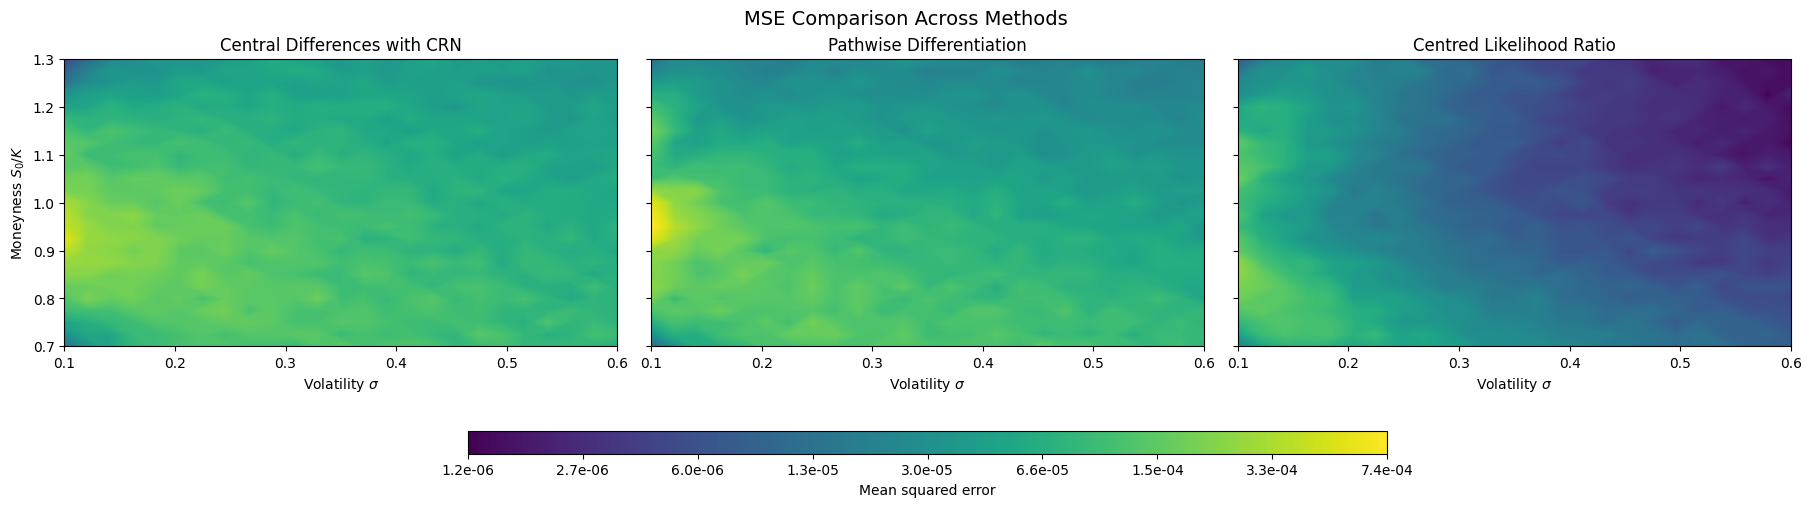

In [40]:
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

# Collect all values to impose a common colour scale
all_mse = np.concatenate([cd_crn_mse.ravel(), pw_mse.ravel(), lr_centred_mse.ravel()])

# Find bounds of obtained data
mse_vmin = all_mse.min()
mse_vmax = all_mse.max()

# Add many levels for smoother colour transitions and better visualisation
mse_levels = np.geomspace(mse_vmin, mse_vmax, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)

mse_data = [cd_crn_mse, pw_mse, lr_centred_mse]
titles = ["Central Differences with CRN", "Pathwise Differentiation", "Centred Likelihood Ratio"]

for ax, data, title in zip(axes, mse_data, titles):
    contour = ax.contourf(VOL, MONEYNESS, data, levels=mse_levels, norm=LogNorm(vmin=mse_vmin, vmax=mse_vmax), cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel(r"Volatility $\sigma$")

axes[0].set_ylabel(r"Moneyness $S_0/K$")

# Configure colorbar
mse_ticks = np.geomspace(mse_vmin, mse_vmax, 9)
cbar = fig.colorbar(contour, ax=axes, orientation="horizontal", pad=0.12, fraction=0.08, aspect=40, ticks=mse_ticks)
cbar.set_label("Mean squared error")
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter("%.1e"))

fig.suptitle("MSE Comparison Across Methods", fontsize=14)

plt.show()

In [41]:
# Compute factors
cd_crn_runtime_mse = cd_crn_mse * cd_crn_runtime

pw_runtime_mse = pw_mse * pw_runtime

lr_total_runtime = lr_centred_runtime + lr_c_runtime
lr_centred_runtime_mse = lr_centred_mse * lr_total_runtime

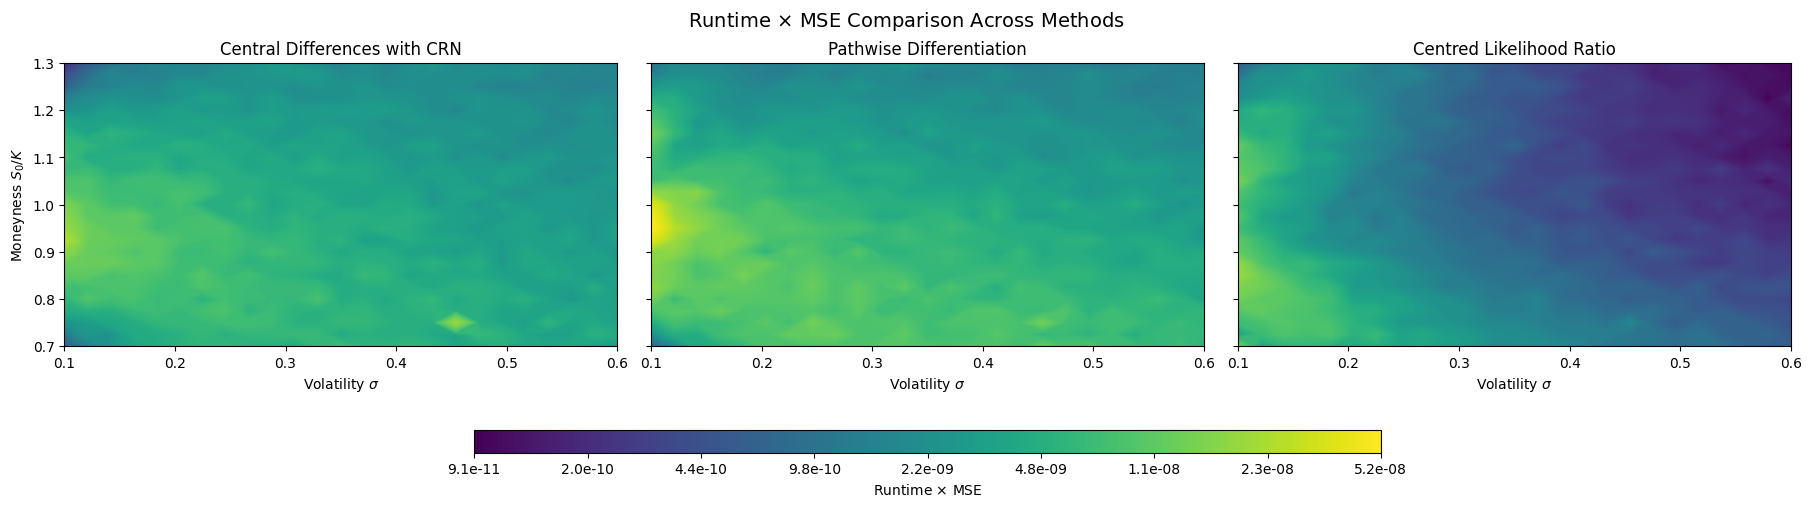

In [42]:
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

all_runtime_mse = np.concatenate([cd_crn_runtime_mse.ravel(), pw_runtime_mse.ravel(), lr_centred_runtime_mse.ravel()])

# Find bounds of data obtained
runtime_mse_vmin = all_runtime_mse.min()
runtime_mse_vmax = all_runtime_mse.max()

runtime_mse_levels = np.geomspace(runtime_mse_vmin, runtime_mse_vmax, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)

runtime_mse_data = [cd_crn_runtime_mse, pw_runtime_mse, lr_centred_runtime_mse]
titles = ["Central Differences with CRN", "Pathwise Differentiation", "Centred Likelihood Ratio"]

for ax, data, title in zip(axes, runtime_mse_data, titles):
    contour = ax.contourf(VOL, MONEYNESS, data, levels=runtime_mse_levels, norm=LogNorm(vmin=runtime_mse_vmin, vmax=runtime_mse_vmax), cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel(r"Volatility $\sigma$")

axes[0].set_ylabel(r"Moneyness $S_0/K$")

# Configure colorbar
runtime_mse_ticks = np.geomspace(runtime_mse_vmin, runtime_mse_vmax, 9)
cbar = fig.colorbar(contour, ax=axes, orientation="horizontal", pad=0.12, fraction=0.08, aspect=40, ticks=runtime_mse_ticks)
cbar.set_label(r"Runtime $\times$ MSE")
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter("%.1e"))

fig.suptitle(r"Runtime $\times$ MSE Comparison Across Methods", fontsize=14)

plt.show()

We observe that the Likelihood-Ratio method with Payoff Centring dominates equally under both metrics across practically the entire grid, and especially on the high-volatility region. Additionally, the Pathwise Differentiation method, which dominates for European and Asian calls, is in this occasion arguably the worst estimator, especially on the moneyness $= 1$ region and under the Runtime x MSE metric. This is due to the fact that Digital call options have a discontinuous payoff function, and the modification required to approximate the discontinuous payoff function through a continuous function increases the MSE of the estimations. In general, this suggests that for options with discontinuous payoff functions (and no closed-form formula for Delta, which does not happen here), the Likelihood-Ratio method is more suitable.